# Import libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from collections import Counter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Get the results dada into a dataset and compute the gap to PHS and gap to OPT metrics

In [2]:
# Define options
family_cols = ['num_warehouses', 'num_customers', 'capacity_distribution']
num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

# Initialize an empty list to store dataframes
results_list = []

# Loop through parameter combinations
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        for capacity_distribution in capacity_distribution_options:
            # Construct the filename
            filename = f'results/full_tables/full_results_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv'
            read_df = pd.read_csv(filename)

            # Keep the last stored result for each policy (in case of multiple runs)
            read_df = read_df.drop_duplicates(subset='Policy', keep='last').reset_index(drop=True)

            # Create a new dataframe
            new_df = pd.DataFrame()
            new_df['num_warehouses'] = [num_warehouses] * len(read_df)
            new_df['num_customers'] = [num_customers] * len(read_df)
            new_df['capacity_distribution'] = [capacity_distribution] * len(read_df)

            # Add all the relevant columns from the read dataframe
            new_df['policy'] = read_df['Policy']
            new_df['avg_reward'] = read_df['MeanReward']
            new_df['std_reward'] = read_df['StdReward']
            new_df['mean_time'] = read_df['MeanTime']
            new_df['std_time'] = read_df['StdTime']
            new_df['all_rewards'] = read_df['AllRewards'].apply(lambda x: eval(x) if isinstance(x, str) else x)
            new_df['all_distance_ranks_n_vectors'] = read_df['AllFacilityProximity'].apply(lambda x: eval(x) if isinstance(x, str) else x)
            new_df['all_distance_ranks_single_vector'] = new_df['all_distance_ranks_n_vectors'].apply(lambda x: [item for sublist in x for item in sublist] if isinstance(x, list) else [])
            new_df['all_times_n_vectors'] = read_df['AllTimes'].apply(lambda x: eval(x) if isinstance(x, str) else x)
            new_df['all_times_single_vector'] = new_df['all_times_n_vectors'].apply(lambda x: [item for sublist in x for item in sublist] if isinstance(x, list) else [])
            new_df['median_time'] = new_df['all_times_single_vector'].apply(lambda x: np.median(x) if isinstance(x, list) and len(x) > 0 else np.nan)

            # Append to list
            results_list.append(new_df)

# Concatenate all dataframes into a single DataFrame
results = pd.concat(results_list, ignore_index=True)

family_cols = ['num_warehouses', 'num_customers', 'capacity_distribution']


def _as_reward_array(x):
    if isinstance(x, str):
        return np.asarray(ast.literal_eval(x), dtype=float)
    return np.asarray(x, dtype=float)


def _family_of(r):
    return results[(results['num_warehouses'] == r['num_warehouses']) &
                   (results['num_customers'] == r['num_customers']) &
                   (results['capacity_distribution'] == r['capacity_distribution'])]


# Comparison against PHS (Perfect Hindsight Solution)

def _row_stats_phs(r):
    fam = _family_of(r)
    phs_cost = -_as_reward_array(fam[fam['policy'] == 'perfect_hindsight']['all_rewards'].iloc[0])
    cost_pi = -_as_reward_array(r['all_rewards'])

    assert len(cost_pi) == len(phs_cost), "episodes not aligned - cannot pair"
    assert (r['policy'] == 'perfect_hindsight') or ((cost_pi - phs_cost) >= 0).all(), \
        f"PHS not per-episode optimal vs {r['policy']} - episodes misaligned"

    delta = cost_pi - phs_cost
    avg_phs = phs_cost.mean()
    avg_delta, std_delta = delta.mean(), delta.std(ddof=1)
    return pd.Series({
        'delta_phs_vector': delta,
        'avg_delta_phs': avg_delta,
        'std_delta_phs': std_delta,
        'gap_phs_vector': delta / phs_cost * 100.0,
        'avg_gap_phs': avg_delta / avg_phs * 100.0,
        'std_gap_phs': std_delta / avg_phs * 100.0,
    })

results[['delta_phs_vector', 'avg_delta_phs', 'std_delta_phs',
         'gap_phs_vector','avg_gap_phs', 'std_gap_phs']] = results.apply(_row_stats_phs, axis=1)

# Comparison against OPT (Optimal policy)

def _row_stats_evf(r):
    empty = pd.Series({
        'delta_optimal_vector': np.array([]),
        'avg_delta_optimal': np.nan, 'std_delta_optimal': np.nan,
        'avg_gap_optimal': np.nan, 'std_gap_optimal': np.nan,
    })
    fam = _family_of(r)
    evf_rows = fam[fam['policy'] == 'exact_value_function']
    if evf_rows.empty:
        return empty

    evf_cost = -_as_reward_array(evf_rows['all_rewards'].iloc[0])
    cost_pi = -_as_reward_array(r['all_rewards'])
    delta = cost_pi - evf_cost
    avg_evf = evf_cost.mean()
    avg_delta, std_delta = delta.mean(), delta.std(ddof=1)
    return pd.Series({
        'delta_optimal_vector': delta,
        'avg_delta_optimal': avg_delta,
        'std_delta_optimal': std_delta,
        'avg_gap_optimal': avg_delta / avg_evf * 100.0,
        'std_gap_optimal': std_delta / avg_evf * 100.0,
    })

results[['delta_optimal_vector', 'avg_delta_optimal', 'std_delta_optimal',
         'avg_gap_optimal', 'std_gap_optimal']] = results.apply(_row_stats_evf, axis=1)

# quick sanity print (PHS family_gap should be ~0)
_phs_gap = results.loc[results['policy'] == 'perfect_hindsight', 'avg_gap_phs']
print("Consolidation done.", f"results: {len(results)} rows (policy x family).")
if not _phs_gap.empty:
    print(f"  PHS family_gap (should be ~0): {_phs_gap.abs().max():.6f}")

Consolidation done. results: 382 rows (policy x family).
  PHS family_gap (should be ~0): 0.000000


# Define a common visual identity to be used in all graphs

In [3]:
COLOR_PALETTE = [
     '#2b83ba', '#fdae61', '#abdda4','#d7191c','#ffffbf'
]

# Uniform font sizes applied to every plot's axis labels, tick labels, and legend below.
TITLE_FONT_SIZE = 12         # plot title
FONT_SIZE_LABEL = 12          # xlabel / ylabel
FONT_SIZE_TICK = 12           # x/y tick labels
FONT_SIZE_LEGEND = 12         # legend entries
FONT_SIZE_LEGEND_TITLE = 12   # legend title

def get_colors(n):
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#33a02c', '#fb9a99', 
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
     "#e704eb", "#000000"
]

plt.style.use(['science', 'muted', 'no-latex'])

# Figure 8 -> Policy comparison over solution quality and online runtime

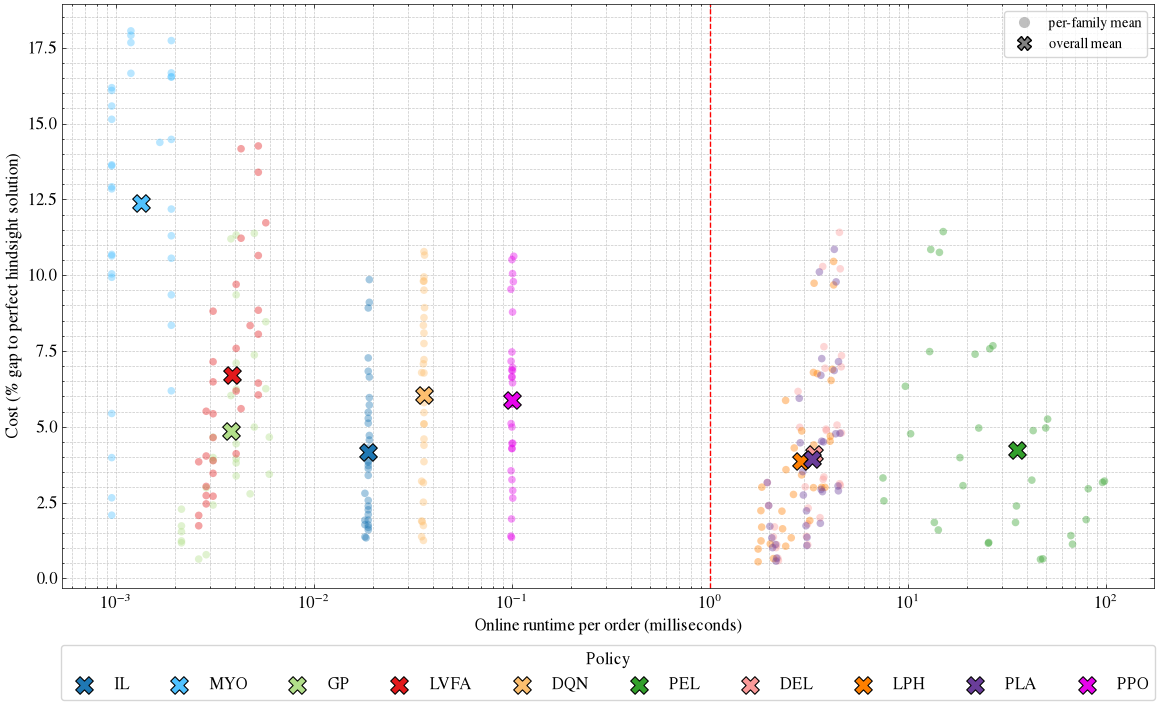

In [4]:
#Policies ordered and respectively labeled for the legend in the scatter plot

policies = ["imitation_learning",
            "myopic", "genetic_programming",
            "linear_value_function_approximation","deep_q_networks",
            "point_estimate_lookahead","distributional_estimate_lookahead",
            "linear_programming_heuristic","parameterized_lookahead_approximation", "proximal_policy_optimization"]
labels_dict = {'myopic': 'MYO', 'imitation_learning': 'IL', 'genetic_programming': 'GP',
               'point_estimate_lookahead': 'PEL', 'distributional_estimate_lookahead': 'DEL',
               'linear_value_function_approximation': 'LVFA', 'deep_q_networks': 'DQN',
               'linear_programming_heuristic': 'LPH', 'linear_programming_exact': 'LPE',
               'parameterized_lookahead_approximation': 'PLA', 'proximal_policy_optimization': 'PPO'}

all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#e31a1c', '#fdbf6f',
   '#33a02c', '#fb9a99', '#ff7f00', '#6a3d9a',
    "#e704eb", "#000000"
]

fig, ax = plt.subplots(figsize=(12, 8))
for p in policies:
    sub = results[results['policy'] == p]
    if sub.empty:
        continue
    color = all_policy_colors[policies.index(p)]

    # faint per-family dots (one per instance family) - softened via low alpha
    ax.scatter(
        sub['median_time'] / 1_000_000,          # ns -> ms
        sub['avg_gap_phs'],
        color=color,
        alpha=0.40,
        s=30,
        edgecolors='none',
        zorder=2,
    )

    # vivid marker at the policy's overall mean
    ax.scatter(
        sub['median_time'].mean() / 1_000_000,
        sub['avg_gap_phs'].mean(),
        color=color,
        marker='X',
        s=160,
        edgecolors='black',
        linewidths=0.8,
        label=labels_dict[p],
        zorder=3,
    )

ax.set_xscale('log')
ax.axvline(1, color='red', linestyle='--')
ax.set_xlabel('Online runtime per order (milliseconds)', fontsize=FONT_SIZE_LABEL)
ax.set_ylabel('Cost (% gap to perfect hindsight solution)', fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

fig.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.22)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Policy', title_fontsize=FONT_SIZE_LEGEND_TITLE,
           loc='lower center', fontsize=FONT_SIZE_LEGEND,
           bbox_to_anchor=(0.525, 0.07), ncol=11, frameon=True)

marker_legend = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='gray', markeredgecolor='none',
           alpha=0.5, markersize=8, label='per-family mean'),
    Line2D([0], [0], marker='X', linestyle='none', markerfacecolor='gray', markeredgecolor='black',
           markersize=10, label='overall mean'),
]
ax.legend(handles=marker_legend, loc='upper right', fontsize=FONT_SIZE_LEGEND - 2, frameon=True)

fig.savefig('results/plots/scatter_time_performance_family_dots.pdf', bbox_inches='tight', dpi=600)
plt.show()

# Figures 9 and 10 -> Analysis of the frequency of non-myopic decisions

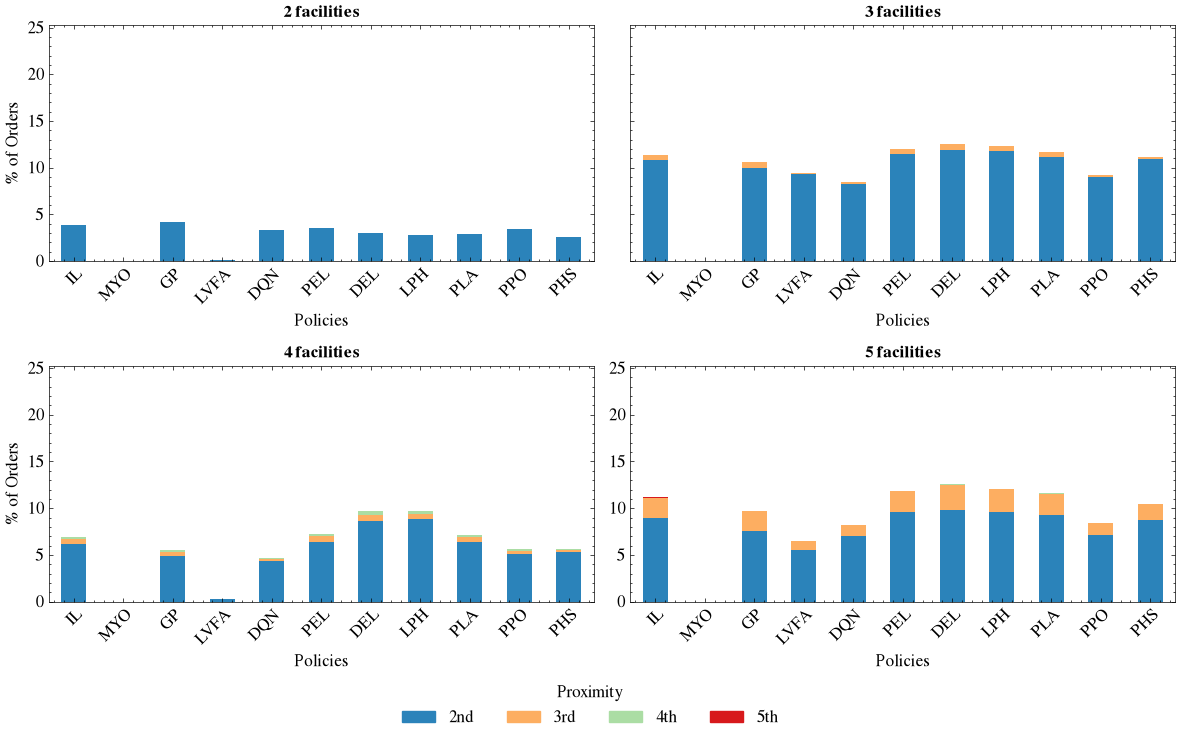

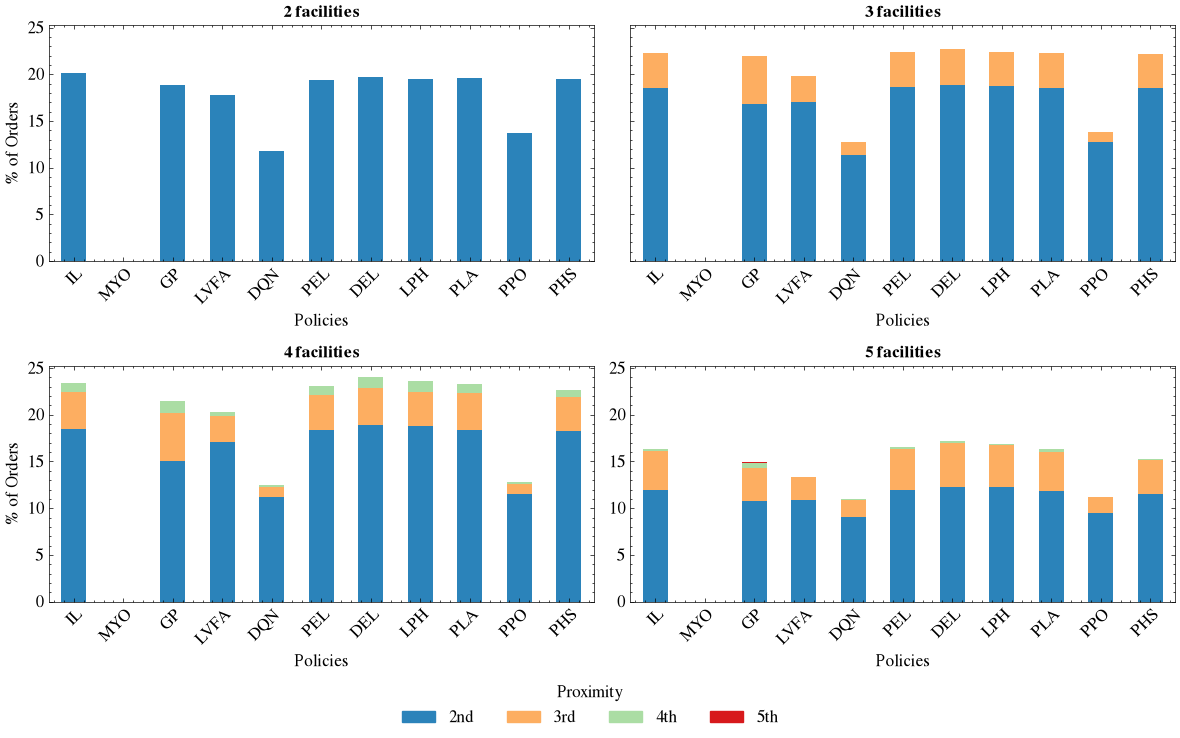

In [5]:
# Get the ordinal representation of a number (e.g., 1 -> 1st, 2 -> 2nd, 3 -> 3rd, etc.)
def _ordinal(n):
    n = int(n)
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

# Build a DataFrame for non-closest proximity ranks
def build_non_closest_df(df_cfg, num_warehouses, policy_order_with_phs):
    rows = []

    for policy in policy_order_with_phs:
        policy_rows = df_cfg[df_cfg["policy"] == policy]
        if policy_rows.empty:
            continue

        # Pool every matching row's ranks together (e.g. one row per num_customers)
        flat_ranks = []
        for ranks in policy_rows["all_distance_ranks_single_vector"]:
            if not isinstance(ranks, list):
                continue
            for r in ranks:
                if isinstance(r, list):
                    flat_ranks.extend(r)
                else:
                    flat_ranks.append(int(r))

        total = len(flat_ranks)
        if total == 0:
            continue

        # Get the percentage of orders that were assigned to each proximity rank (2nd, 3rd, etc.)
        counts = Counter(r for r in flat_ranks if 2 <= int(r) <= num_warehouses)
        for prox_rank, count in counts.items():
            rows.append(
                {
                    "policy": policy,
                    "proximity": _ordinal(prox_rank),
                    "rank_pct": 100 * count / total,
                }
            )

    return pd.DataFrame(rows)


# Policy order and labels
policy_order = ["imitation_learning", "myopic", "genetic_programming", "linear_value_function_approximation", "deep_q_networks", "point_estimate_lookahead", "distributional_estimate_lookahead", "linear_programming_heuristic", "parameterized_lookahead_approximation", "proximal_policy_optimization", "perfect_hindsight"]
labels_dict = {'myopic': 'MYO', 'imitation_learning': 'IL', 'genetic_programming': 'GP', 'point_estimate_lookahead': 'PEL', 'distributional_estimate_lookahead': 'DEL', 'linear_value_function_approximation': 'LVFA', 'deep_q_networks': 'DQN', 'linear_programming_heuristic': 'LPH', 'linear_programming_exact': 'LPE', 'parameterized_lookahead_approximation': 'PLA', 'perfect_hindsight': 'PHS', 'proximal_policy_optimization': 'PPO'}

x_labels_with_phs = [labels_dict.get(p, p) for p in policy_order]
x_pos_with_phs = list(range(len(policy_order)))

# Proximity categories and colors
proximity_categories = [_ordinal(r) for r in range(2, max(num_warehouses_options) + 1)]
category_colors = dict(zip(proximity_categories, get_colors(len(proximity_categories))))

pivots = {}
global_ymax = 0
for capacity_distribution in capacity_distribution_options:
    for num_warehouses in num_warehouses_options:
        df_cfg = results[
            (results["num_warehouses"] == num_warehouses)
            & (results["capacity_distribution"] == capacity_distribution)
        ]
        df_plot = build_non_closest_df(df_cfg, num_warehouses, policy_order)
        if df_plot.empty:
            continue

        pivot = (
            df_plot.pivot_table(
                index="policy",
                columns="proximity",
                values="rank_pct",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(index=policy_order, columns=proximity_categories)
            .fillna(0)
        )
        pivots[(capacity_distribution, num_warehouses)] = pivot
        global_ymax = max(global_ymax, pivot.sum(axis=1).max())

global_ymax *= 1.05  # small headroom so the tallest bar isn't flush with the frame

for capacity_distribution in capacity_distribution_options:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, num_warehouses in zip(axes, num_warehouses_options):
        pivot = pivots.get((capacity_distribution, num_warehouses))
        if pivot is None:
            ax.set_axis_off()
            continue

        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            legend=False,
            color=[category_colors[c] for c in pivot.columns],
        )

        ax.set_title(f"{num_warehouses} facilities", fontsize=TITLE_FONT_SIZE)
        ax.title.set_fontweight("bold")
        ax.set_xlabel("Policies", fontsize=FONT_SIZE_LABEL)
        ax.set_ylabel("% of Orders", fontsize=FONT_SIZE_LABEL)
        ax.set_xticklabels(x_labels_with_phs, rotation=45, ha="right", rotation_mode="anchor", fontsize=FONT_SIZE_TICK)
        ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, labelleft=True)
        ax.set_ylim(0, global_ymax)

    # turn off any axes left over when fewer than 4 num_warehouses configs are loaded
    for ax in axes[len(num_warehouses_options):]:
        ax.set_axis_off()

    handles = [mpatches.Patch(color=category_colors[cat], label=cat) for cat in proximity_categories]
    fig.legend(handles=handles, title="Proximity", loc="lower center", bbox_to_anchor=(0.5, +0.01), ncol=len(proximity_categories), fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(f'results/plots/proximity_rank_plots/proximity_rank_distribution_{capacity_distribution}.pdf', bbox_inches='tight', dpi=600)
    plt.show()